In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
P=2

In [11]:
from maineigen import *

Updated alpha from OCC file. Alpha=0.001
OCC_dualbar.geo
1 air bar2
[0, 1, 2] 3 ['air', 'bar1', 'bar2']
Mesh Contains Prisms? False
N Prisms: 0, N Tets: 8052
1 air bar2
[0, 1, 2] 3 ['air', 'bar1', 'bar2']
 mesh contains 8052 elements
Running Bilinear Forms Check
Mesh curve order set to:  5
K: Iteration 1: bonus_intord = 2
K: Iteration 2: bonus_intord = 4
K Bilinear Form Converged using order 6
C: Iteration 1: bonus_intord = 2
C: Iteration 2: bonus_intord = 4
C Bilinear Form Converged using order 6


Solving Theta0: 100%|██████████████████████████| 3/3 [00:00<00:00, 96791.63it/s]


 solved theta0 problems    
[[ 1.05974573e-19  4.40734262e-44 -4.97152813e-44]
 [ 4.40734262e-44  1.05974573e-19  1.33536603e-43]
 [-4.97152813e-44  1.33536603e-43  1.05974573e-19]]


Solving Thetainf: 100%|███████████████████████████| 3/3 [00:01<00:00,  2.92it/s]


 solved thetainf problems   


Solving Theta1: 100%|█████████████████████████| 3/3 [00:00<00:00, 103991.01it/s]


 solved theta1 problem       
 Computing coefficients  
 mesh contains 8052 elements
Running Bilinear Forms Check
Mesh curve order set to:  5
K: Iteration 1: bonus_intord = 2
K: Iteration 2: bonus_intord = 4
K Bilinear Form Converged using order 6
C: Iteration 1: bonus_intord = 2
C: Iteration 2: bonus_intord = 4
C Bilinear Form Converged using order 6
Completed setting up xivecgfu
0 : [1190.5366185550995, 1435.9499141021042, 1610.4262207783215, 1836.9760967578677, 2259.0241777101573, 2553.1465656418563, 2899.9951774787723, 3585.189540419189, 3633.4469978631355, 3909.5696517810657, 4028.7235651045553, 4505.215667183491, 4549.413654610484, 5084.104578605971, 5156.887434016958, 5270.190191185989, 5880.656174000423, 5915.317093538399, 6284.6691003103115, 6576.092527883806, 6652.2900652688095, 7208.482992265981, 7392.954468557285, 7769.723235993283, 8014.702530831889, 8100.265863715075, 8476.79260007928, 8749.44389100926, 9009.194212503902, 9121.435174461169, 9325.387521855078, 9619.7007003

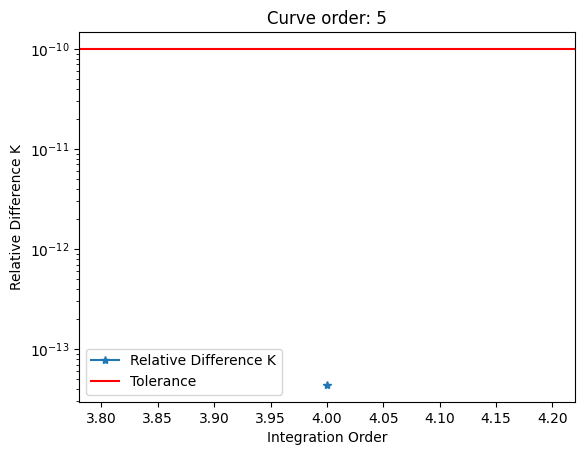

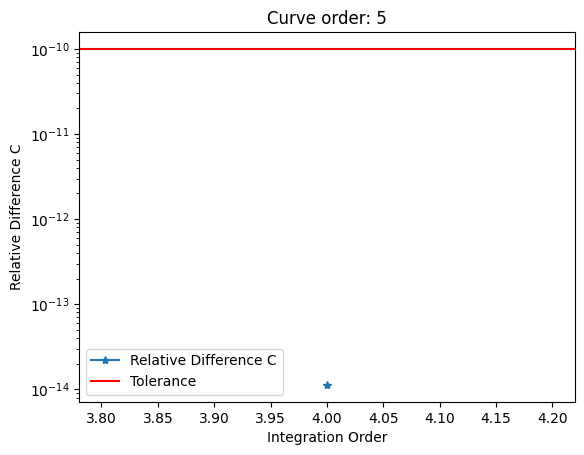

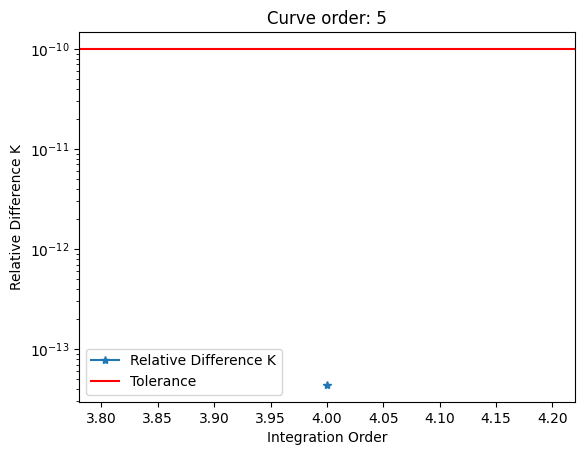

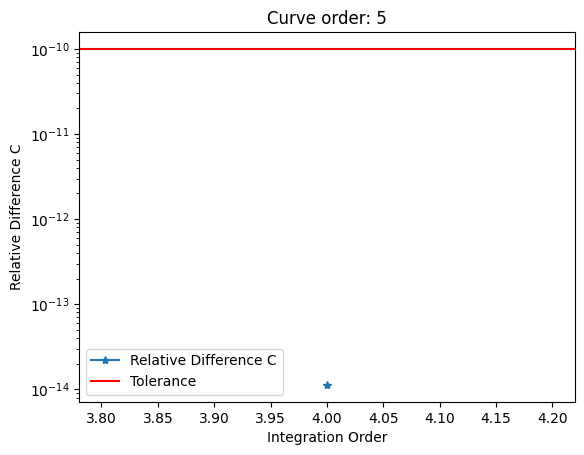

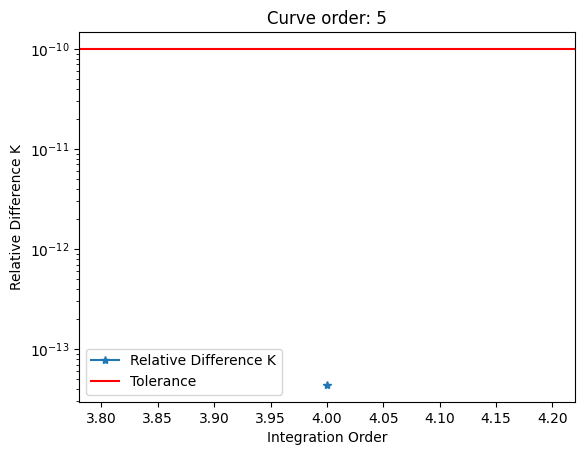

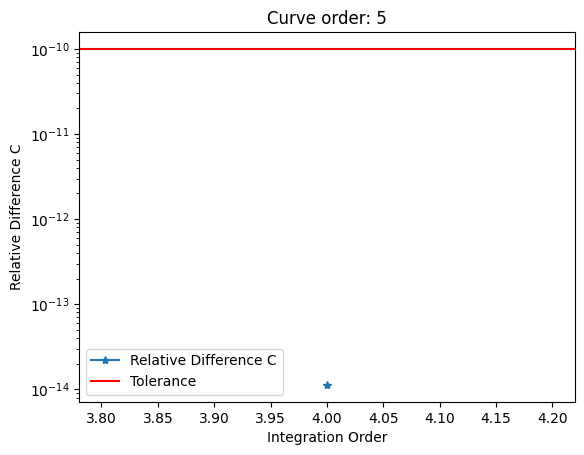

In [12]:
xi,ck, sMPT, Omega =maineigen(h='coarse', order=P, curve_degree=5, geometry='OCC_dualbar.py', start_stop=(1,12,40), use_OCC=True)

In [13]:
# Data Dual Bar
path="/Users/pdl11/Coding/PaulResults/PaulMPTResults/Results/OCC_dualbar/al_0.001_mu_1,1_sig_1e6,1e8/1e1-1e12_200_el_57195_ord_5_POD_13_1e-6/Data/"
Frequencies=np.loadtxt(path+"Frequencies.csv",dtype=float)
Frequencies_ob=Frequencies
Tensors=np.loadtxt(path+"Tensors.csv",delimiter=',',dtype=complex)
Tensors=np.conj(Tensors)

Eigenvalues_ob=np.loadtxt(path+"Eigenvalues.csv",delimiter=',',dtype=complex)
N0_ob=np.loadtxt(path+"N0.csv",delimiter=',',dtype=float)


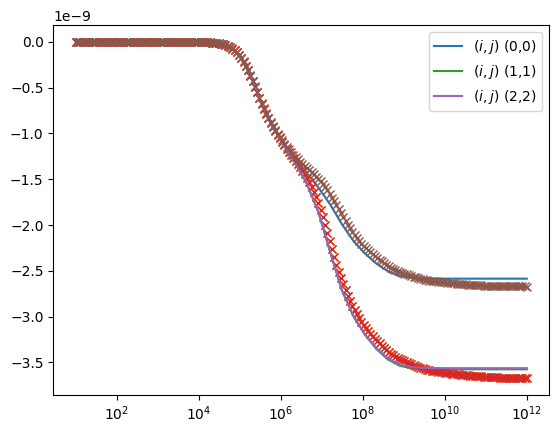

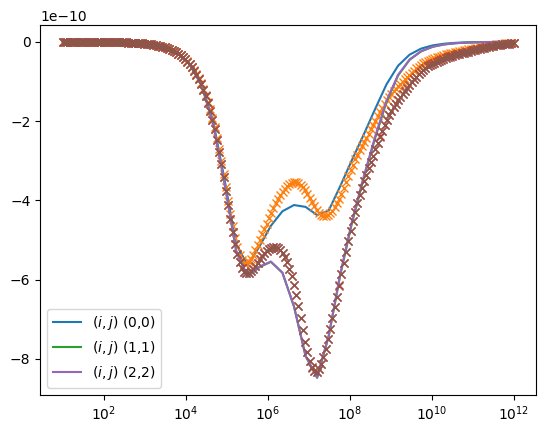

In [14]:
Omega
plt.figure(1)
plt.figure(2)
for i in range(3):
    for j in range(3):
        if j == i :
            plt.figure(1)
            plt.semilogx(Omega,np.real(sMPT[:,i,j]),label="$(i,j)$ ("+str(i)+","+str(j)+")")
            plt.semilogx(Frequencies,np.real(Eigenvalues_ob[:,i]),'x')
           
            plt.figure(2)

            plt.semilogx(Omega,np.imag(sMPT[:,i,j]),label="$(i,j)$ ("+str(i)+","+str(j)+")")
            plt.semilogx(Frequencies,-np.imag(Eigenvalues_ob[:,i]),'x')
    
        #if j < i :
        #    plt.figure(1)
        #    plt.semilogx(Omega,np.real(sMPT[:,i,j]),label="$(i,j)$ ("+str(i)+","+str(j)+")")
            
        #    plt.figure(2)
        #    plt.semilogx(Omega,-np.imag(sMPT[:,i,j]),label="$(i,j)$ ("+str(i)+","+str(j)+")")
plt.figure(1)
plt.legend()

plt.figure(2)
plt.legend()

/var/folders/4l/kd3nw5rs03s946hxc6b0d8xc000mpb/T/ipykernel_31131/3411556695.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xi[:])), ck[:,1,1],'b',label=r"Approximate")
/Users/pdl11/anaconda3/envs/py13testing_mac/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pdl11/anaconda3/envs/py13testing_mac/lib/python3.13/site-packages/numpy/ma/core.py:3473: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/Users/pdl11/anaconda3/envs/py13testing_mac/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, '$\\tilde{c}_k/(2\\pi \\alpha^3) $')

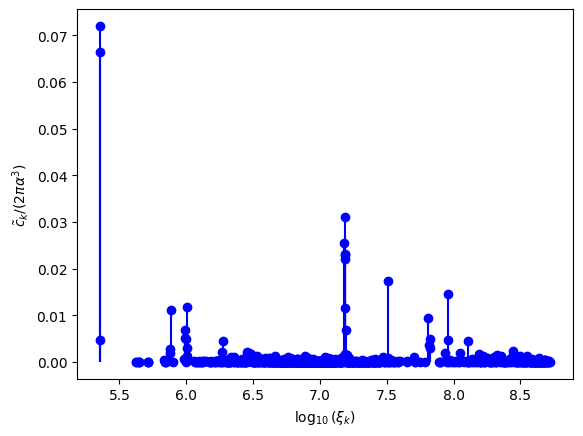

In [15]:
plt.stem(np.log10(np.abs(xi[:])), ck[:,1,1],'b',label=r"Approximate")
plt.xlabel(r"$\log_{10} (\xi_k)$")
plt.ylabel(r"$\tilde{c}_k/(2\pi \alpha^3) $")